### 1. Import packages

In [1]:
import os, sys, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
import math

import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier, SklearnClassifier

from art_generator import (
    FGSMAttackGenerator, PGDAttackGenerator, CWAttackGenerator,
    DeepFoolAttackGenerator, MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config

### 2. Surrogate MLP architecture

In [2]:
class _SurrogateMLP(nn.Module):
    """Simple 3-layer MLP — intentionally different from ResDNN and LSTM."""
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)

class _ScaledMLP(nn.Module):
    """Wraps MLP with embedded scaler so ART operates in raw feature space."""
    def __init__(self, mlp, mean, scale):
        super().__init__()
        self.mlp = mlp
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.float()
        return self.mlp((x - self.mean_) / self.scale_)

### 3. Load data

In [4]:
DEVICE = 'cpu'

# Test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

# Training data (for surrogate)
df_train = pd.read_csv('../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Masking: protect binary/categorical features
mutate_indices = get_mutate_indices(df_test)
print(f'Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}')
print(f'Protected features (binary/categorical): {len(mutate_indices)} indices')

Train: (9600, 66), Test: (2028, 66), Classes: 12
Protected features (binary/categorical): 12 indices


### 4. Train surrogate MLP

In [5]:
# Scale data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# DataLoaders
train_ds = TensorDataset(torch.from_numpy(X_train_sc), torch.from_numpy(y_train).long())
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

# Train
torch.manual_seed(42)
surrogate = _SurrogateMLP(input_dim, num_classes).to(DEVICE)
optimizer = torch.optim.AdamW(surrogate.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    surrogate.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(surrogate(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        surrogate.eval()
        with torch.no_grad():
            preds = torch.argmax(surrogate(torch.from_numpy(X_test_sc).to(DEVICE)), dim=1).cpu().numpy()
        acc = accuracy_score(y_test, preds)
        print(f'Epoch {epoch+1}: test acc = {acc*100:.2f}%')

surrogate.eval()
print('Surrogate training done.')

Epoch 20: test acc = 67.80%
Epoch 40: test acc = 68.15%
Epoch 60: test acc = 69.38%
Epoch 80: test acc = 69.63%
Epoch 100: test acc = 69.63%
Surrogate training done.


### 5. Create ART classifier (surrogate)

In [6]:
# Wrap with scaler for ART
scaled_surrogate = _ScaledMLP(surrogate, scaler.mean_, scaler.scale_).to(DEVICE)
scaled_surrogate.eval()

surrogate_clf = PyTorchClassifier(
    model=scaled_surrogate,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

# Verify surrogate accuracy
preds = np.argmax(surrogate_clf.predict(X_test), axis=1)
print(f'Surrogate accuracy on test: {accuracy_score(y_test, preds)*100:.2f}%')

Surrogate accuracy on test: 69.63%


### 6. Helper functions

In [7]:
def evaluate_attack(y_true, y_pred_proba, attack_name):
    preds = np.argmax(y_pred_proba, axis=1) if y_pred_proba.ndim > 1 else y_pred_proba
    acc = accuracy_score(y_true, preds) * 100
    f1 = f1_score(y_true, preds, average='macro')
    print(f'--- {attack_name} ---')
    print(f'Accuracy: {acc:.2f}%, Macro-F1: {f1:.4f}')
    return preds

def save_adv_csv(adv_samples, y, feature_names, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(adv_samples, columns=feature_names)
    df['Label'] = y
    df.to_csv(path, index=False)
    print(f'Saved: {path}')

### 7. Generate whitebox attacks from surrogate

In [8]:
SURR_ADV_DIR = '../../adv_samples/adv_eval/surrogate'
os.makedirs(SURR_ADV_DIR, exist_ok=True)

input_metadata = {
    'feature_names': feature_names,
    'label_column': 'Label',
}

# Map attack name → generator class
ATTACK_MAP = {
    'fgsm':     FGSMAttackGenerator,
    'pgd':      PGDAttackGenerator,
    'deepfool': DeepFoolAttackGenerator,
    'cw':       CWAttackGenerator,
    'mim':      MIMAttackGenerator,
}

# Load params from YAML configs instead of hardcoding
ATTACK_NAMES = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']
attacks = {}
for atk in ATTACK_NAMES:
    cfg = load_attack_config(atk)
    generator_cls = ATTACK_MAP[atk]
    attacks[atk] = generator_cls(surrogate_clf, generator_params=cfg)

surrogate_adv = {}
for atk_name, generator in attacks.items():
    print(f'\n=== Generating {atk_name.upper()} ===')
    start = time.time()
    df_adv = generator.generate(X_test, y_test, input_metadata, mutate_indices=mutate_indices)
    runtime = time.time() - start
    print(f'Runtime: {runtime:.2f}s')

    adv = df_adv.drop(columns=['Label']).values.astype(np.float32)

    # Evaluate on surrogate itself
    preds_adv = surrogate_clf.predict(adv)
    evaluate_attack(y_test, preds_adv, f'{atk_name.upper()} (on surrogate)')

    # Save
    path = f'{SURR_ADV_DIR}/surrogate_{atk_name}_adv.csv'
    df_adv.to_csv(path, index=False)
    print(f'Saved: {path}')
    surrogate_adv[atk_name] = adv


=== Generating FGSM ===
Runtime: 0.05s
--- FGSM (on surrogate) ---
Accuracy: 24.46%, Macro-F1: 0.1410
Saved: ../../adv_samples/adv_eval/surrogate/surrogate_fgsm_adv.csv

=== Generating PGD ===


Runtime: 4.36s
--- PGD (on surrogate) ---
Accuracy: 18.44%, Macro-F1: 0.1631
Saved: ../../adv_samples/adv_eval/surrogate/surrogate_pgd_adv.csv

=== Generating DEEPFOOL ===


DeepFool: 100%|██████████| 32/32 [00:00<00:00, 48.48it/s]


Runtime: 0.67s
--- DEEPFOOL (on surrogate) ---
Accuracy: 0.30%, Macro-F1: 0.0024
Saved: ../../adv_samples/adv_eval/surrogate/surrogate_deepfool_adv.csv

=== Generating CW ===
Runtime: 1.91s
--- CW (on surrogate) ---
Accuracy: 33.04%, Macro-F1: 0.3079
Saved: ../../adv_samples/adv_eval/surrogate/surrogate_cw_adv.csv

=== Generating MIM ===


Runtime: 2.13s
--- MIM (on surrogate) ---
Accuracy: 7.79%, Macro-F1: 0.0362
Saved: ../../adv_samples/adv_eval/surrogate/surrogate_mim_adv.csv


In [17]:
# ── Load pre-generated surrogate adversarial CSVs ──
SURR_ADV_DIR = '../../adv_samples/adv_eval/surrogate'
ATTACK_NAMES = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']

surrogate_adv = {}
for atk_name in ATTACK_NAMES:
    path = f'{SURR_ADV_DIR}/surrogate_{atk_name}_adv.csv'
    if not os.path.exists(path):
        print(f'[SKIP] {path} not found')
        continue
    df_adv = pd.read_csv(path)
    surrogate_adv[atk_name] = df_adv.drop(columns=['Label']).values.astype(np.float32)
    print(f'Loaded {atk_name.upper():>10s}: {surrogate_adv[atk_name].shape}')

print(f'\nLoaded {len(surrogate_adv)}/{len(ATTACK_NAMES)} surrogate attacks')

Loaded       FGSM: (2028, 66)
Loaded        PGD: (2028, 66)
Loaded   DEEPFOOL: (2028, 66)
Loaded         CW: (2028, 66)
Loaded        MIM: (2028, 66)

Loaded 5/5 surrogate attacks


### 8. Load target models

In [18]:
# ── Target model architectures (needed for LSTM and ResDNN) ──

# ResDNN
class _ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.25):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.ln2  = nn.LayerNorm(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        return torch.relu(self.ln2(x + self.lin2(h)))

class _ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.stem   = nn.Sequential(nn.Linear(in_dim, W), nn.BatchNorm1d(W), nn.ReLU(), nn.Dropout(0.30))
        self.block1 = _ResidualBlock(W, W // 2, p=0.30)
        self.block2 = _ResidualBlock(W, W // 2, p=0.25)
        self.block3 = _ResidualBlock(W, W // 2, p=0.20)
        self.head   = nn.Linear(W, n_classes)
    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(self.stem(x)))))

class _ScaledResDNN(nn.Module):
    def __init__(self, resdnn, mean, scale):
        super().__init__()
        self.resdnn = resdnn
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        return self.resdnn(((x.float()) - self.mean_) / self.scale_)

# LSTM
class _AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.proj = nn.Linear(d, 1)
    def forward(self, H):
        w = torch.softmax(self.proj(H).squeeze(-1), dim=1)
        return (H * w.unsqueeze(-1)).sum(1)

class _LSTMTabular(nn.Module):
    def __init__(self, step_dim, hidden=256, layers=2, n_classes=12, dropout=0.15, bidir=True):
        super().__init__()
        self.step_dim = step_dim
        self.in_norm = nn.LayerNorm(step_dim)
        self.lstm = nn.LSTM(input_size=step_dim, hidden_size=hidden, num_layers=layers,
                           batch_first=True, dropout=dropout if layers > 1 else 0.0, bidirectional=bidir)
        d_out = hidden * (2 if bidir else 1)
        self.pool = _AttnPool(d_out)
        self.head = nn.Sequential(nn.Linear(d_out, d_out // 2), nn.ReLU(), nn.Dropout(0.20), nn.Linear(d_out // 2, n_classes))
    def forward(self, x):
        B, F = x.shape
        S = int(math.ceil(F / self.step_dim))
        pad = S * self.step_dim - F
        if pad > 0: x = nn.functional.pad(x, (0, pad))
        x = self.in_norm(x.view(B, S, self.step_dim))
        H, _ = self.lstm(x)
        return self.head(self.pool(H))

class _ScaledLSTM(nn.Module):
    def __init__(self, lstm, mean, scale):
        super().__init__()
        self.lstm = lstm
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        return self.lstm(((x.to(torch.float32)) - self.mean_) / self.scale_)

In [19]:
from art.estimators.classification.catboost import CatBoostARTClassifier
MODEL_DIR = '../../training/models'
target_classifiers = {}
AT_DIR = '../../defense/models'
# ── RF ──
rf_model = joblib.load(f'{MODEL_DIR}/framework_rf_TVAE.pkl')
target_classifiers['RF'] = SklearnClassifier(
    model=rf_model,
    clip_values=(np.min(X_test), np.max(X_test)),
)

# ── CAT ──
cat_model = joblib.load(f'{MODEL_DIR}/framework_cat_TVAE.pkl')
target_classifiers['CAT'] = CatBoostARTClassifier(
    model=cat_model,
    clip_values=(np.min(X_test), np.max(X_test)),
)

# ── ResDNN ──
ckpt_resdnn = torch.load(f'{MODEL_DIR}/framework_resdnn_TVAE.pth', map_location=DEVICE, weights_only=False)

resdnn_net = _ResDNN(in_dim=int(ckpt_resdnn['in_dim']), n_classes=int(ckpt_resdnn['n_classes']))
resdnn_net.load_state_dict(ckpt_resdnn['state_dict'])
resdnn_net.eval()
scaled_resdnn = _ScaledResDNN(resdnn_net, ckpt_resdnn['scaler'].mean_, ckpt_resdnn['scaler'].scale_).to(DEVICE)
scaled_resdnn.eval()
target_classifiers['ResDNN'] = PyTorchClassifier(
    model=scaled_resdnn, loss=nn.CrossEntropyLoss(), input_shape=(input_dim,),
    nb_classes=num_classes, clip_values=(float(X_test.min()), float(X_test.max())), device_type=DEVICE,
)

# ── LSTM ──
ckpt_lstm = torch.load(f'{MODEL_DIR}/framework_lstm_TVAE.pth', map_location=DEVICE, weights_only=False)
lstm_net = _LSTMTabular(
    step_dim=int(ckpt_lstm['step_dim']), hidden=int(ckpt_lstm['hidden']),
    layers=int(ckpt_lstm['layers']), n_classes=int(ckpt_lstm['num_classes']),
    dropout=float(ckpt_lstm['dropout']), bidir=bool(ckpt_lstm['bidir']),
)
lstm_net.load_state_dict(ckpt_lstm['state_dict'])
lstm_net.eval()
scaled_lstm = _ScaledLSTM(lstm_net, ckpt_lstm['scaler'].mean_, ckpt_lstm['scaler'].scale_).to(DEVICE)
scaled_lstm.eval()
target_classifiers['LSTM'] = PyTorchClassifier(
    model=scaled_lstm, loss=nn.CrossEntropyLoss(), input_shape=(input_dim,),
    nb_classes=num_classes, clip_values=(float(X_test.min()), float(X_test.max())), device_type=DEVICE,
)

# Verify target model accuracies
print('=== Target Model Clean Accuracy ===')
for name, clf in target_classifiers.items():
    preds = np.argmax(clf.predict(X_test), axis=1)
    acc = accuracy_score(y_test, preds)
    print(f'{name:>8s}: {acc*100:.2f}%')

=== Target Model Clean Accuracy ===
      RF: 86.09%
     CAT: 86.34%
  ResDNN: 68.89%
    LSTM: 68.10%


### 9. Evaluate transferability (Surrogate → Targets)

In [20]:
print('=== Transferability: Surrogate MLP → Target Models ===')
print(f'{"Attack":>10s} | {"Surrogate":>10s} | {"RF":>10s} | {"CAT":>10s} | {"LSTM":>10s} | {"ResDNN":>10s}')
print('-' * 75)

for atk_name, adv in surrogate_adv.items():
    # Surrogate ASR
    surr_preds = np.argmax(surrogate_clf.predict(X_test), axis=1)
    surr_correct = np.where(y_test == surr_preds)[0]
    surr_adv_preds = np.argmax(surrogate_clf.predict(adv), axis=1)
    surr_asr = np.sum(surr_preds[surr_correct] != surr_adv_preds[surr_correct]) / len(surr_correct) * 100

    row = f'{atk_name.upper():>10s} | {surr_asr:>9.2f}% |'

    # Target ASRs
    for tgt_name, tgt_clf in target_classifiers.items():
        tgt_preds = np.argmax(tgt_clf.predict(X_test), axis=1)
        tgt_correct = np.where(y_test == tgt_preds)[0]
        tgt_adv_preds = np.argmax(tgt_clf.predict(adv), axis=1)
        tgt_asr = np.sum(tgt_preds[tgt_correct] != tgt_adv_preds[tgt_correct]) / len(tgt_correct) * 100
        row += f' {tgt_asr:>9.2f}% |'

    print(row)

=== Transferability: Surrogate MLP → Target Models ===
    Attack |  Surrogate |         RF |        CAT |       LSTM |     ResDNN
---------------------------------------------------------------------------
      FGSM |     80.68% |     57.79% |     58.54% |     74.87% |     46.92% |
       PGD |     90.24% |     56.87% |     56.60% |     81.53% |     41.78% |
  DEEPFOOL |    100.00% |     47.48% |     51.23% |     99.50% |     57.42% |
        CW |     72.27% |     36.43% |     40.43% |     45.03% |     38.96% |
       MIM |     99.14% |     53.84% |     55.80% |     93.06% |     44.10% |


In [21]:
at_classifiers = {}
# for tgt_name in ['rf', 'cat', 'lstm', 'resdnn']:
#     at_classifiers[tgt_name] = joblib.load(f'{AT_DIR}/framework_{tgt_name}_TVAE_at.pkl')
at_resdnn_checkpoint = torch.load(f'{AT_DIR}/framework_resdnn_TVAE_at.pth', map_location=DEVICE, weights_only=False)
at_resdnn = _ResDNN(in_dim=int(at_resdnn_checkpoint['in_dim']), n_classes=int(at_resdnn_checkpoint['n_classes']))   
at_resdnn.load_state_dict(at_resdnn_checkpoint['state_dict'])
at_resdnn.eval()
scaled_at_resdnn = _ScaledResDNN(at_resdnn, at_resdnn_checkpoint['scaler'].mean_, at_resdnn_checkpoint['scaler'].scale_).to(DEVICE)
scaled_at_resdnn.eval()
at_classifiers['resdnn'] = PyTorchClassifier(
    model=scaled_at_resdnn, loss=nn.CrossEntropyLoss(), input_shape=(input_dim,),
    nb_classes=num_classes, clip_values=(float(X_test.min()), float(X_test.max())), device_type=DEVICE,
)

pred_orig = target_classifiers['ResDNN'].predict(X_test)
y_pred_orig = np.argmax(pred_orig, axis=1)
correct_orig = np.where(y_test == y_pred_orig)[0]

pred_adv = at_classifiers['resdnn'].predict(X_test)
y_pred_adv = np.argmax(pred_adv, axis=1)
asr_adv = np.sum(y_pred_orig[correct_orig] != y_pred_adv[correct_orig]) / len(correct_orig) * 100
print(f'ASR: {asr_adv:.2f}%')

for atk_name, adv in surrogate_adv.items():
    print(f'=== {atk_name.upper()} ===')
    pred_orig = at_classifiers['resdnn'].predict(X_test)
    y_pred_orig = np.argmax(pred_orig, axis=1)
    correct_orig = np.where(y_test == y_pred_orig)[0]

    pred_adv = at_classifiers['resdnn'].predict(adv)
    y_pred_adv = np.argmax(pred_adv, axis=1)
    asr_adv = np.sum(y_pred_orig[correct_orig] != y_pred_adv[correct_orig]) / len(correct_orig) * 100
    print(f'ASR: {asr_adv:.2f}%')
# Evaluate on each target model
# for tgt_name, at_clf in at_classifiers.items():
#     print(f'=== {tgt_name.upper()} ===')
#     pred_orig = target_classifiers[tgt_name].predict(X_test)
#     y_pred_orig = np.argmax(pred_orig, axis=1)
#     correct_orig = np.where(y_test == y_pred_orig)[0]

#     pred_adv = at_clf.predict(X_test)
#     y_pred_adv = np.argmax(pred_adv, axis=1)
#     asr_adv = np.sum(y_pred_orig[correct_orig] != y_pred_adv[correct_orig]) / len(correct_orig) * 100
#     print(f'ASR: {asr_adv:.2f}%')


ASR: 22.55%
=== FGSM ===
ASR: 3.14%
=== PGD ===
ASR: 5.95%
=== DEEPFOOL ===
ASR: 8.92%
=== CW ===
ASR: 0.17%
=== MIM ===
ASR: 5.20%


### 10. Save adversarial samples per target model

In [22]:
# Save surrogate adversarial samples labeled per target model
# (same adversarial samples, just organized per target for defense notebooks)
for tgt_name in ['rf', 'cat', 'lstm', 'resdnn']:
    tgt_dir = f'../../adv_samples/adv_eval/{tgt_name}'
    os.makedirs(tgt_dir, exist_ok=True)

    for atk_name, adv in surrogate_adv.items():
        out_path = f'{tgt_dir}/{tgt_name}_surrogate_{atk_name}_adv.csv'
        df_adv = pd.DataFrame(adv, columns=feature_names)
        df_adv['Label'] = y_test
        df_adv.to_csv(out_path, index=False)

    print(f'Saved 5 attacks for {tgt_name}')

print('\nDone! Surrogate adversarial samples saved for all targets.')

Saved 5 attacks for rf
Saved 5 attacks for cat
Saved 5 attacks for lstm
Saved 5 attacks for resdnn

Done! Surrogate adversarial samples saved for all targets.


### 11. Detailed confusion matrices (Surrogate → each target)

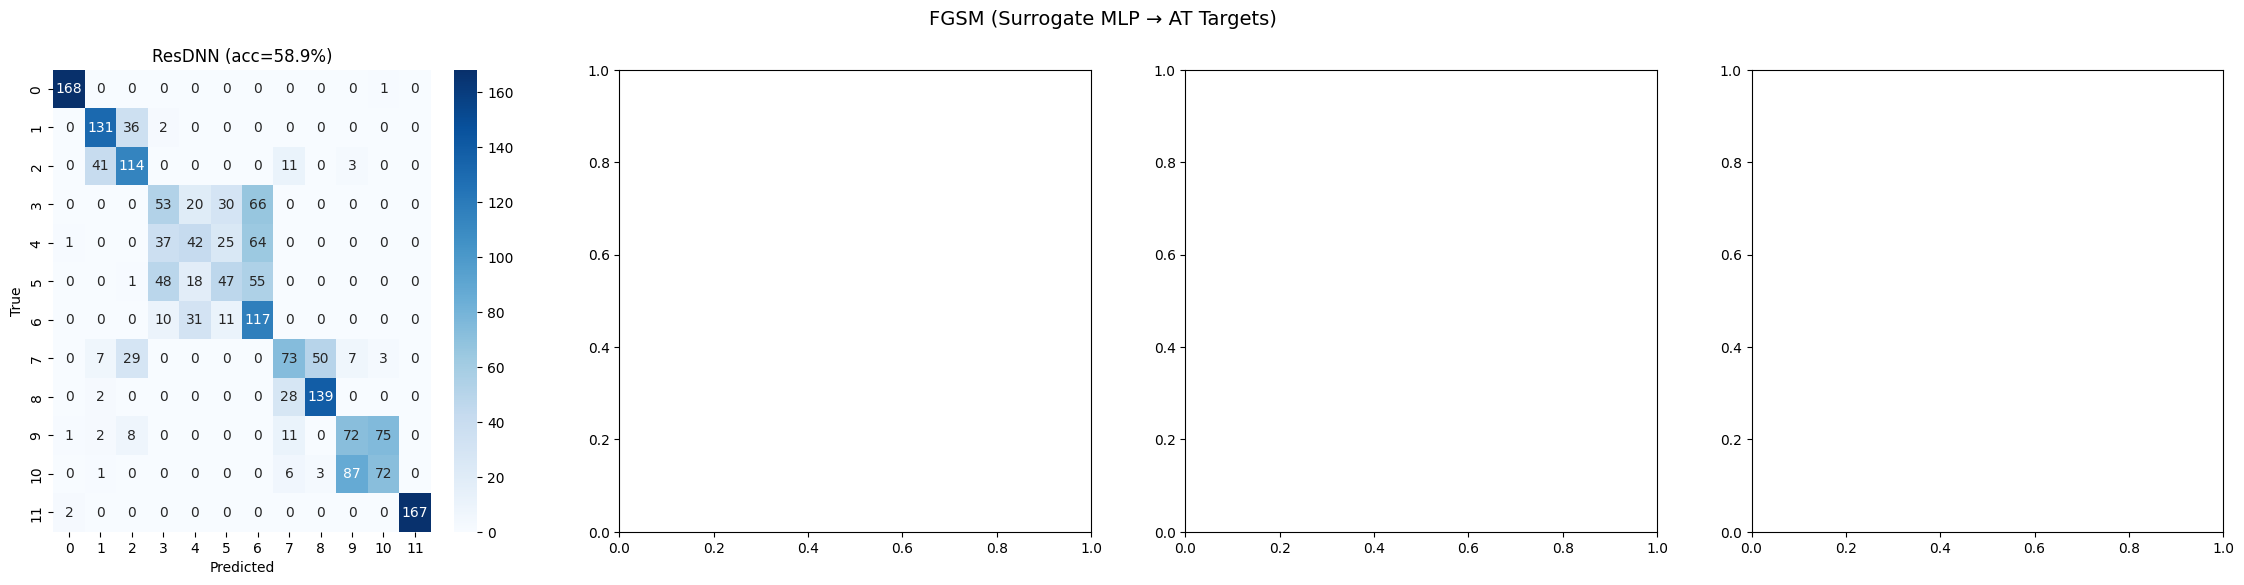

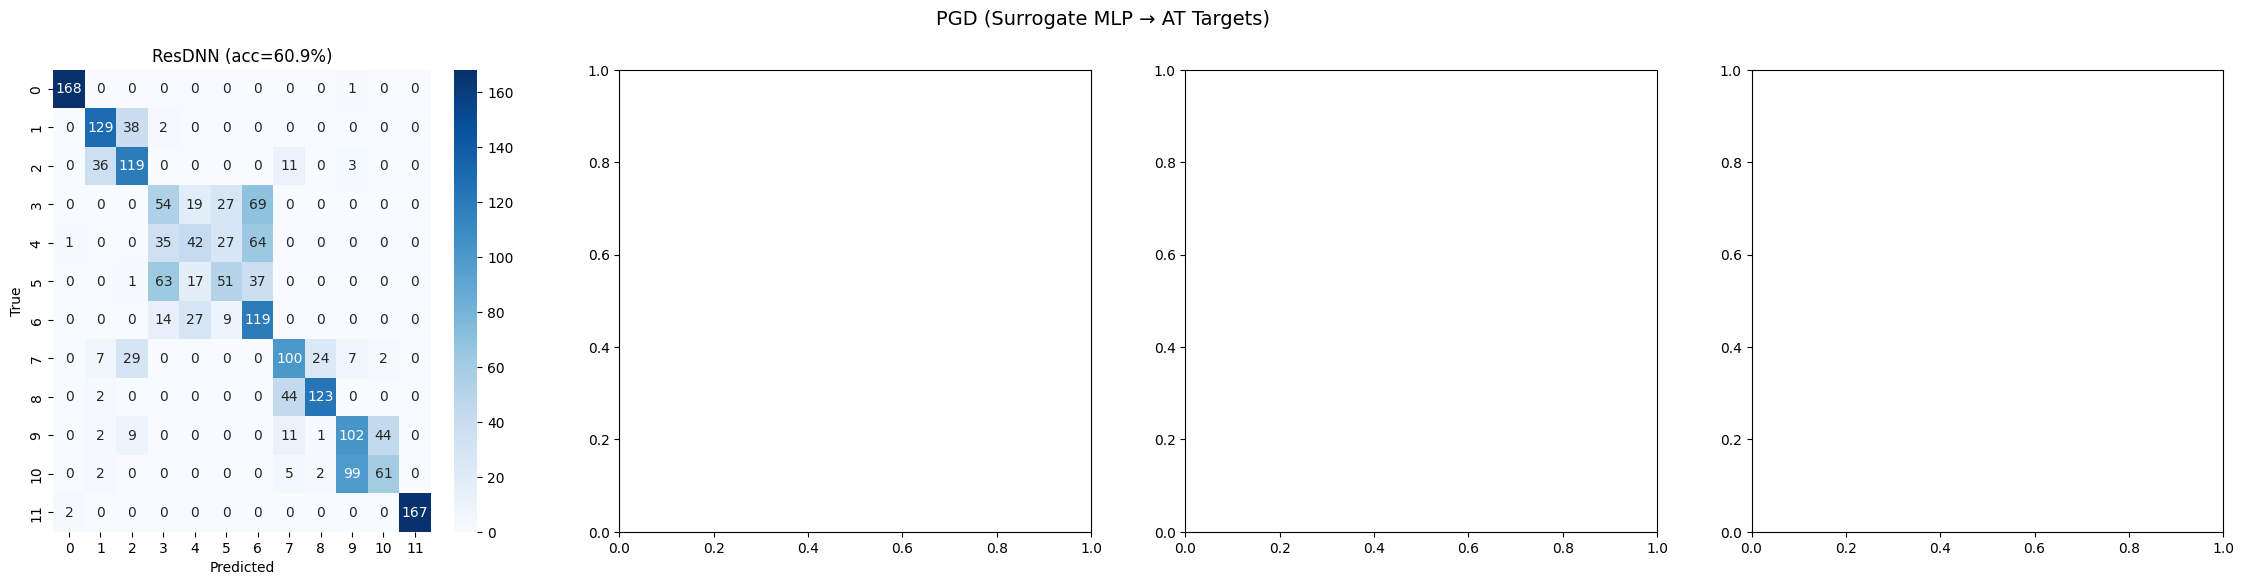

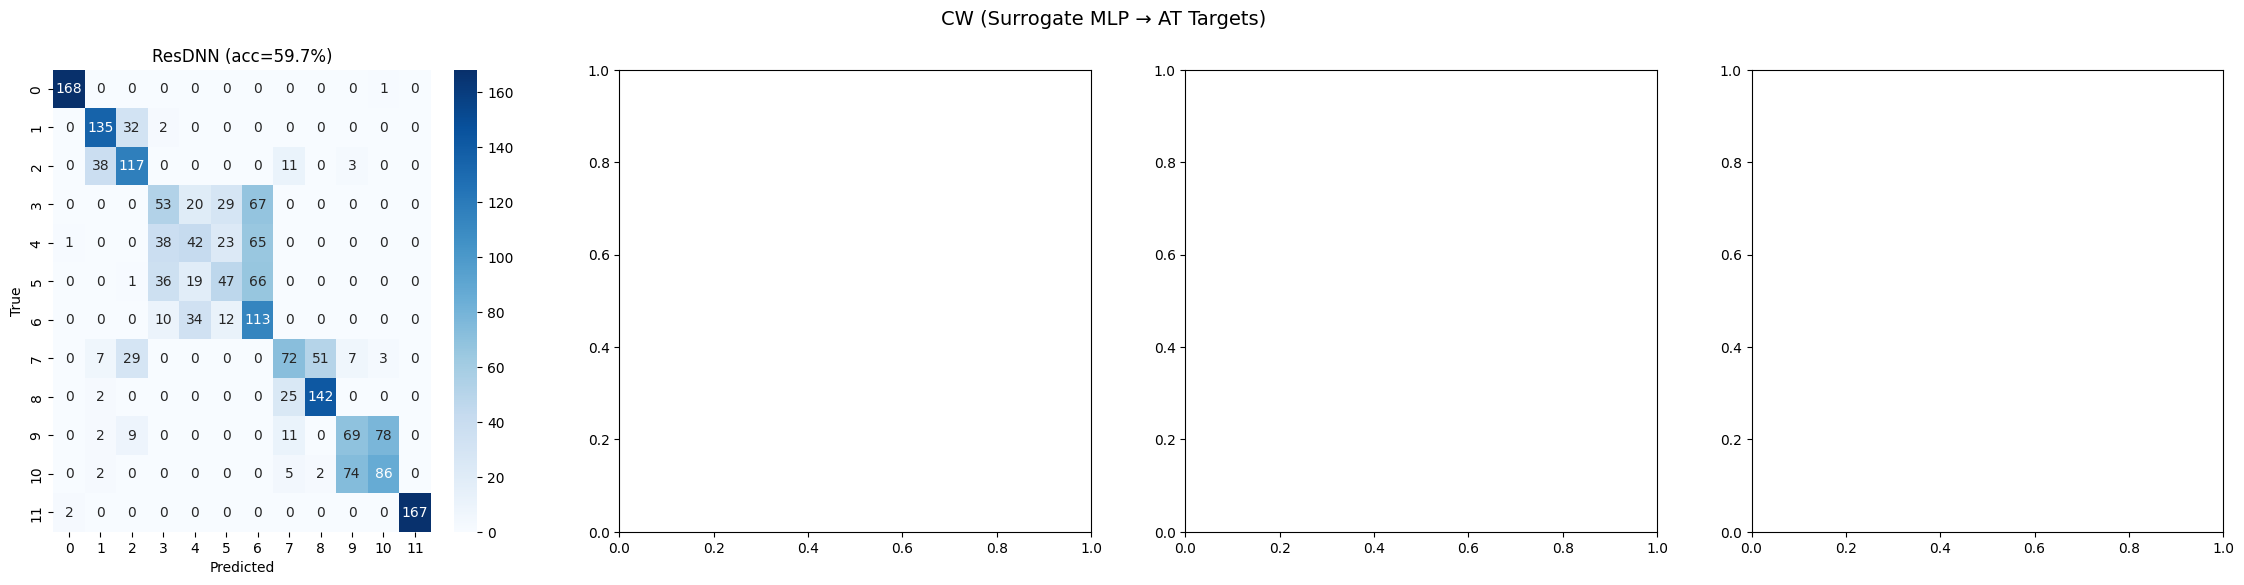

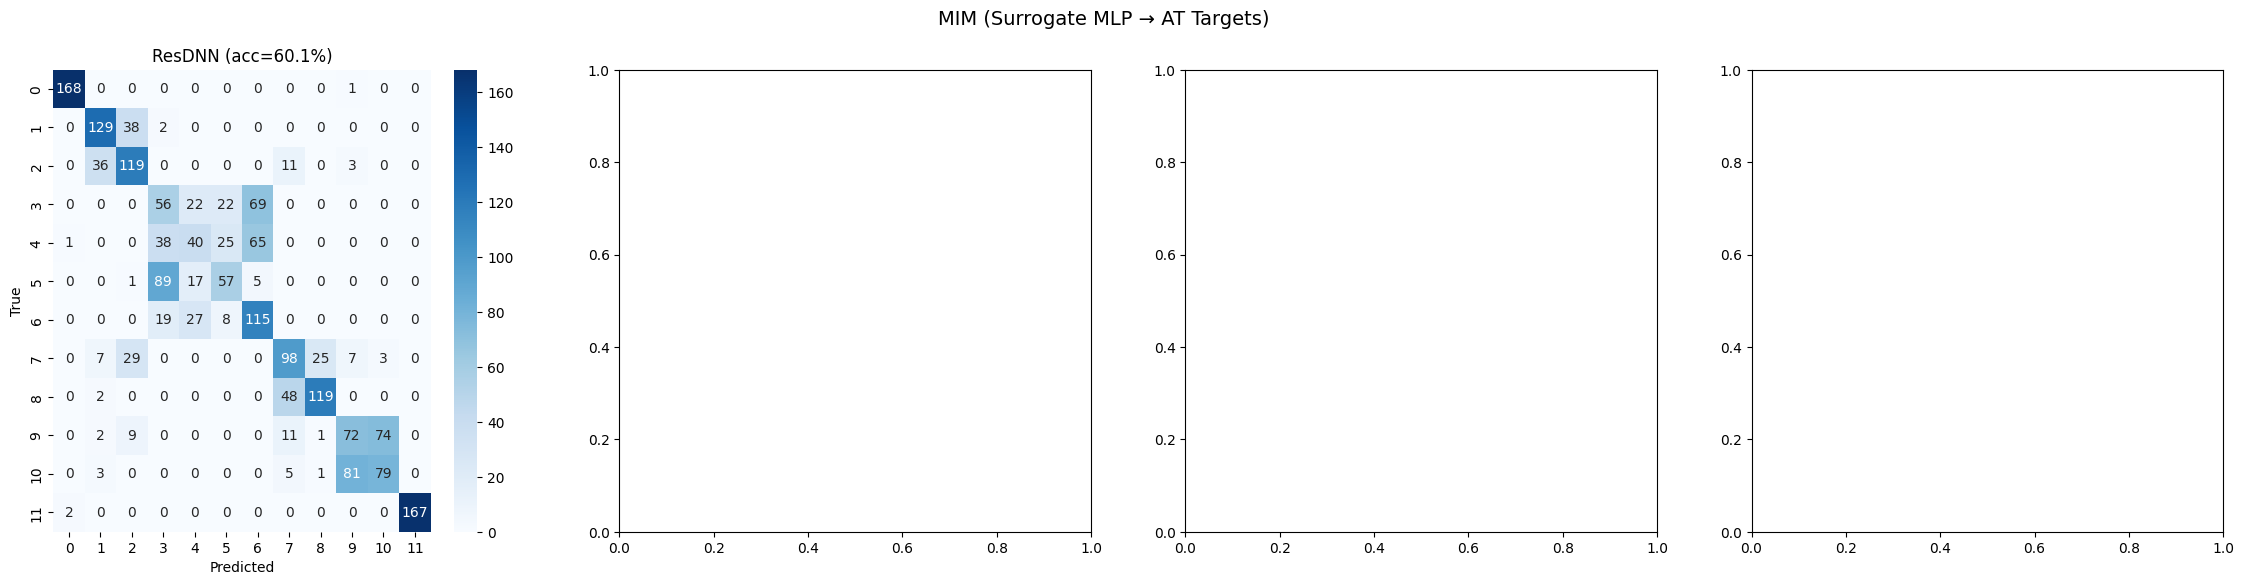

In [23]:
## Confusion Matrix on AT Model
for attack_name in ['fgsm', 'pgd', 'cw', 'mim']:
    adv = surrogate_adv[attack_name]
    fig, axes = plt.subplots(1,4,figsize=(28,6))
    fig.suptitle(f'{attack_name.upper()} (Surrogate MLP → AT Targets)', fontsize=14)
    pred = np.argmax(at_classifiers['resdnn'].predict(adv), axis=1)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    acc = accuracy_score(y_test, pred) * 100
    axes[0].set_title(f'ResDNN (acc={acc:.1f}%)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

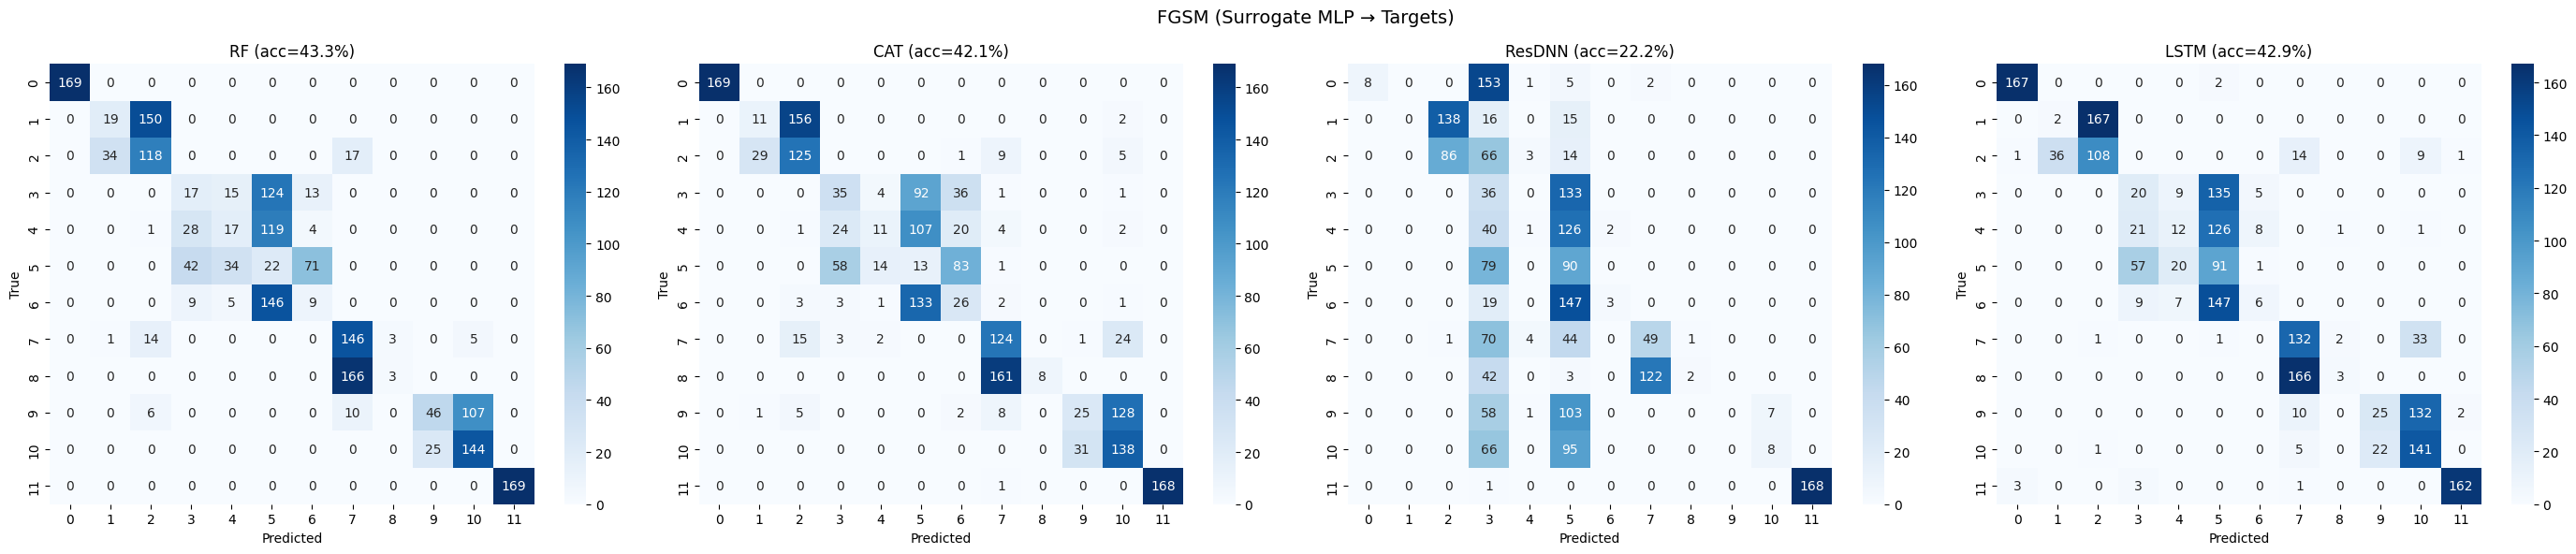

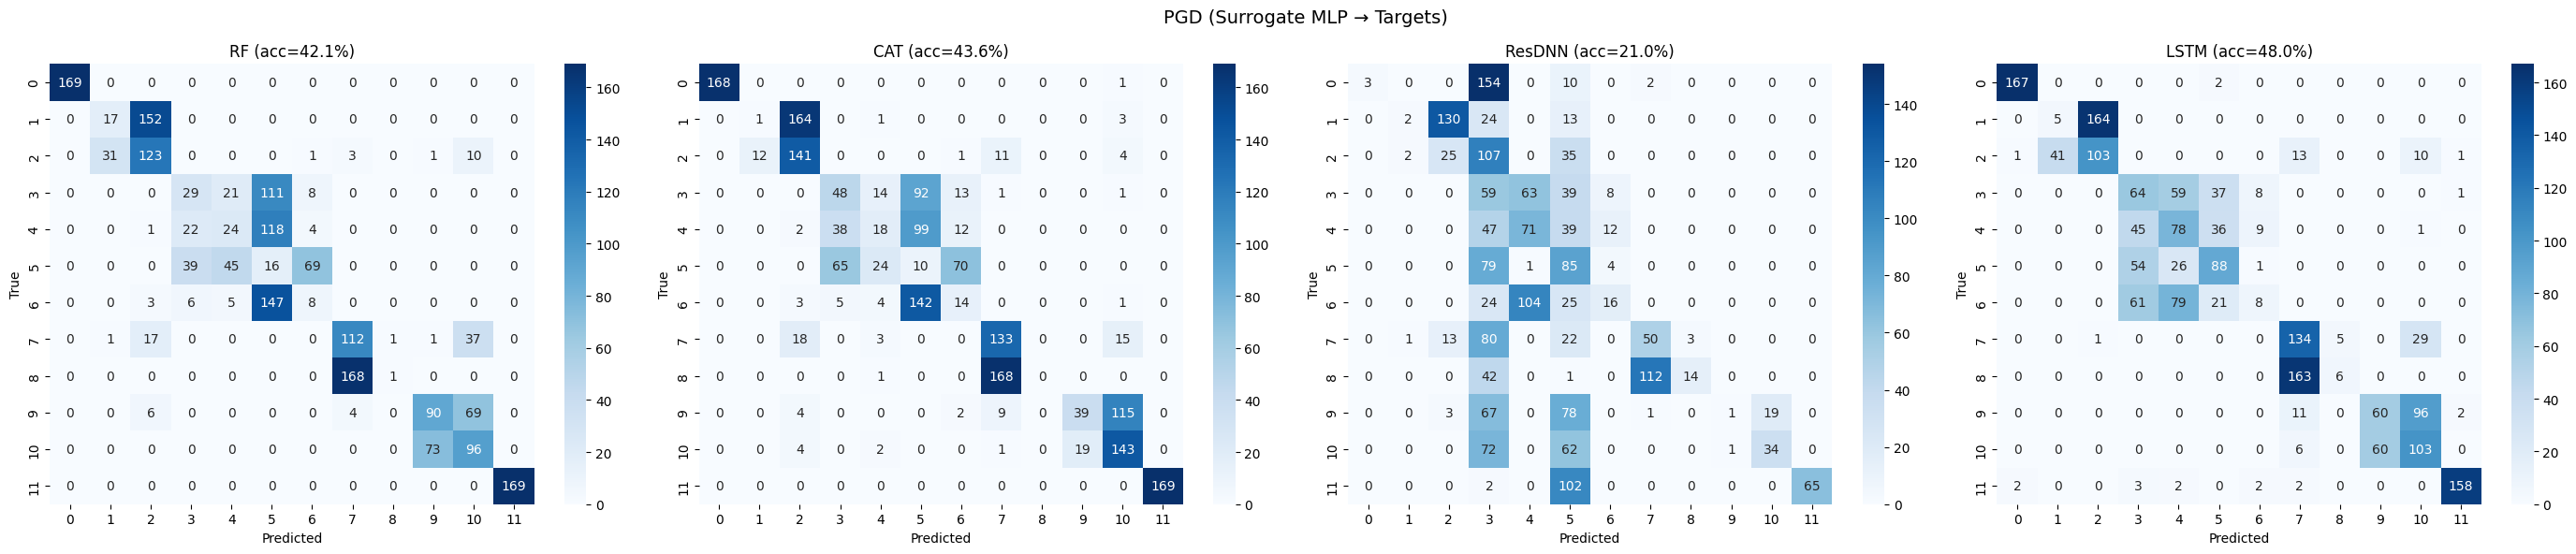

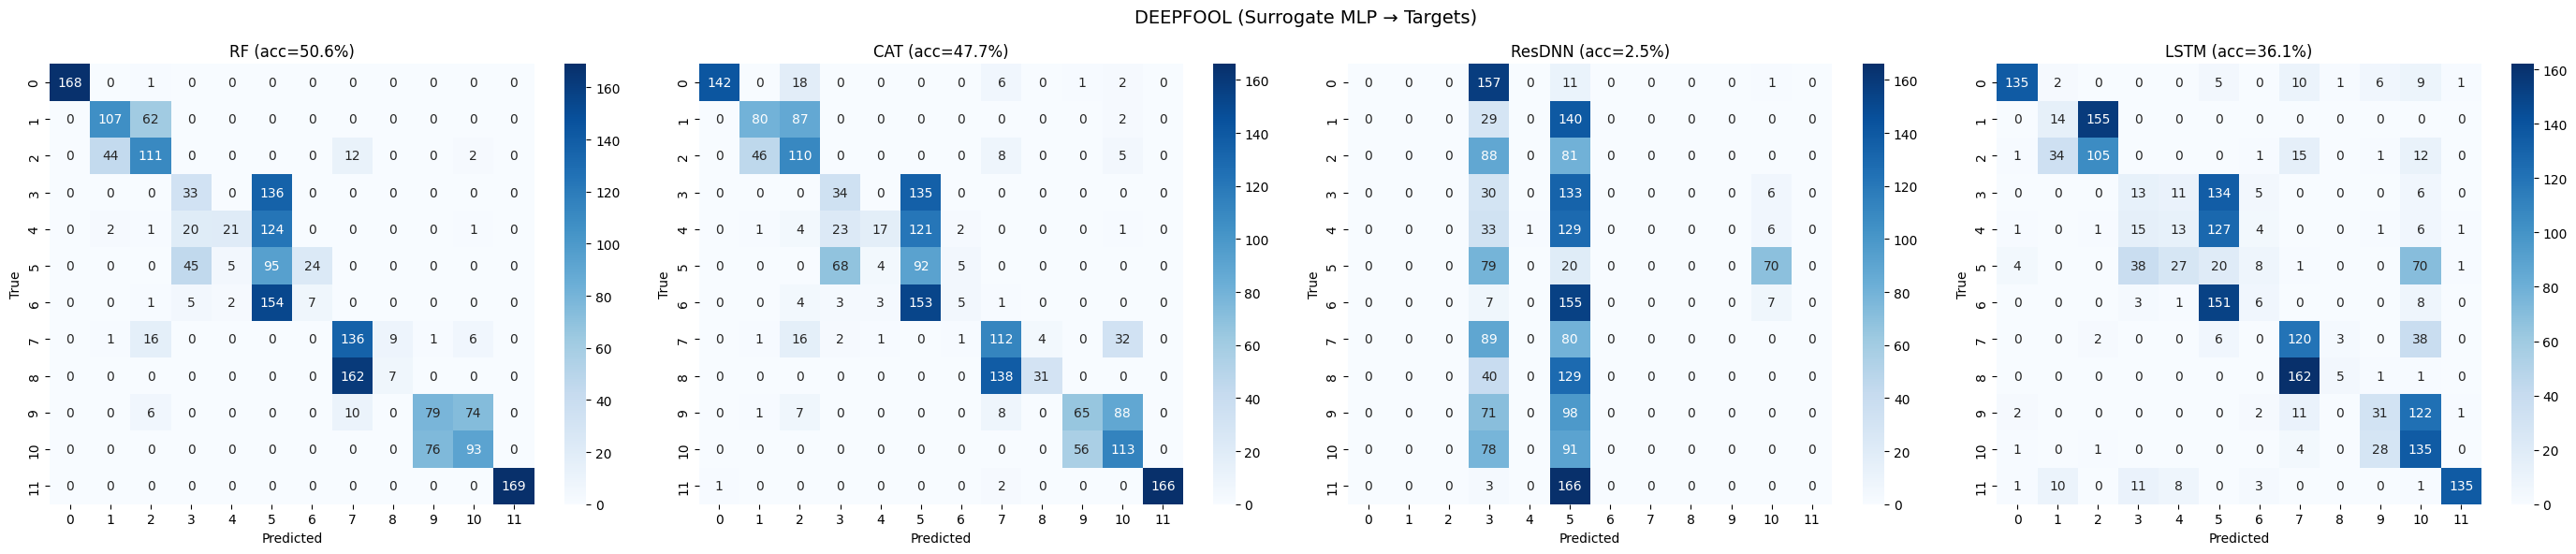

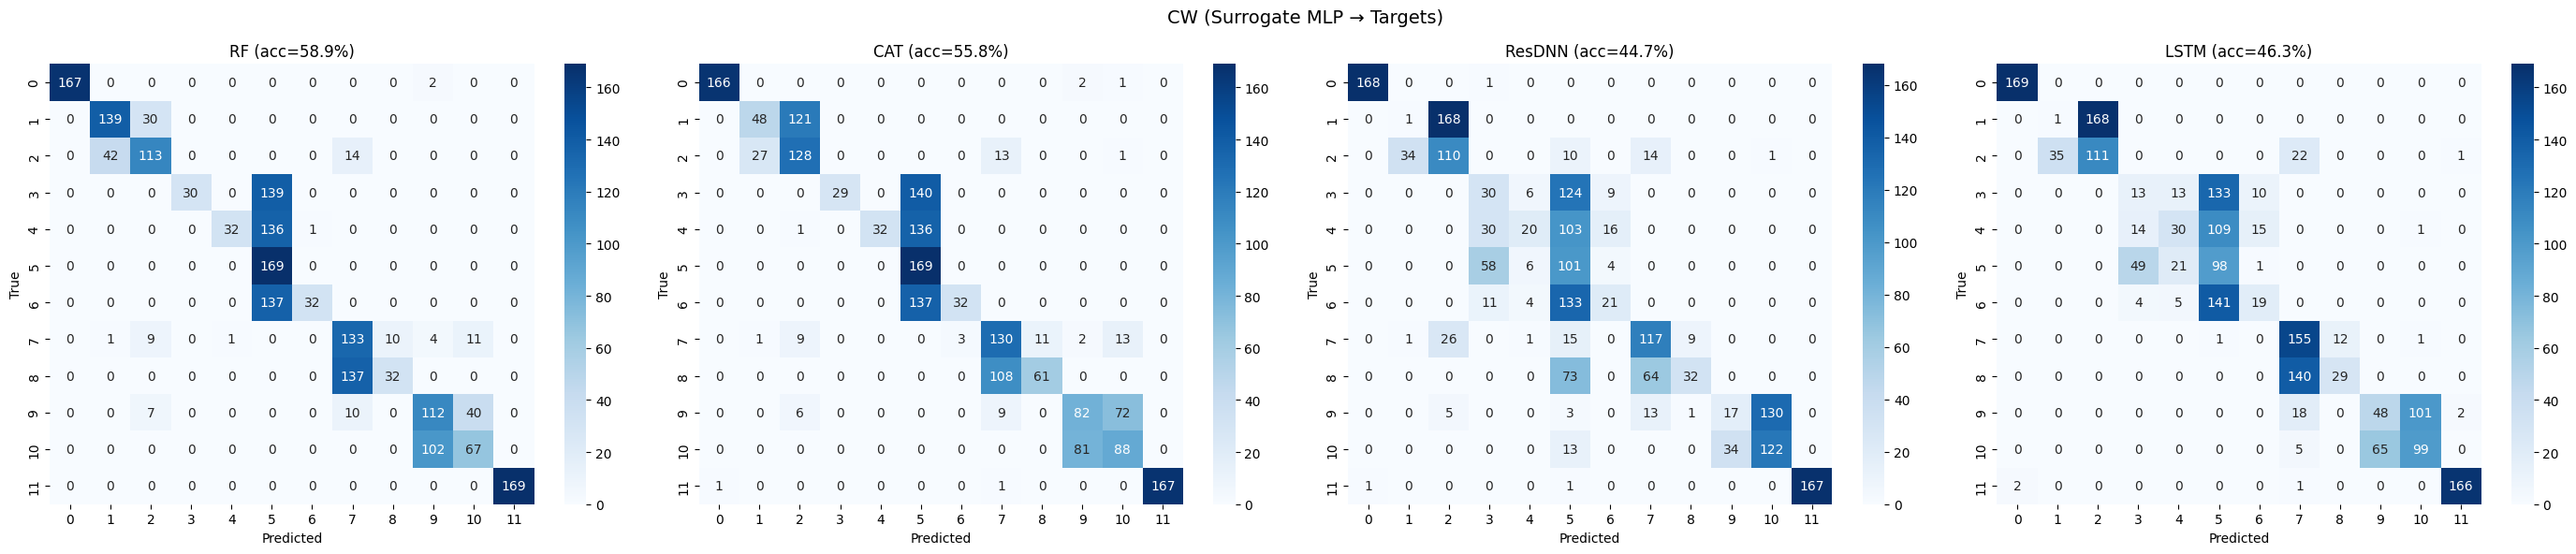

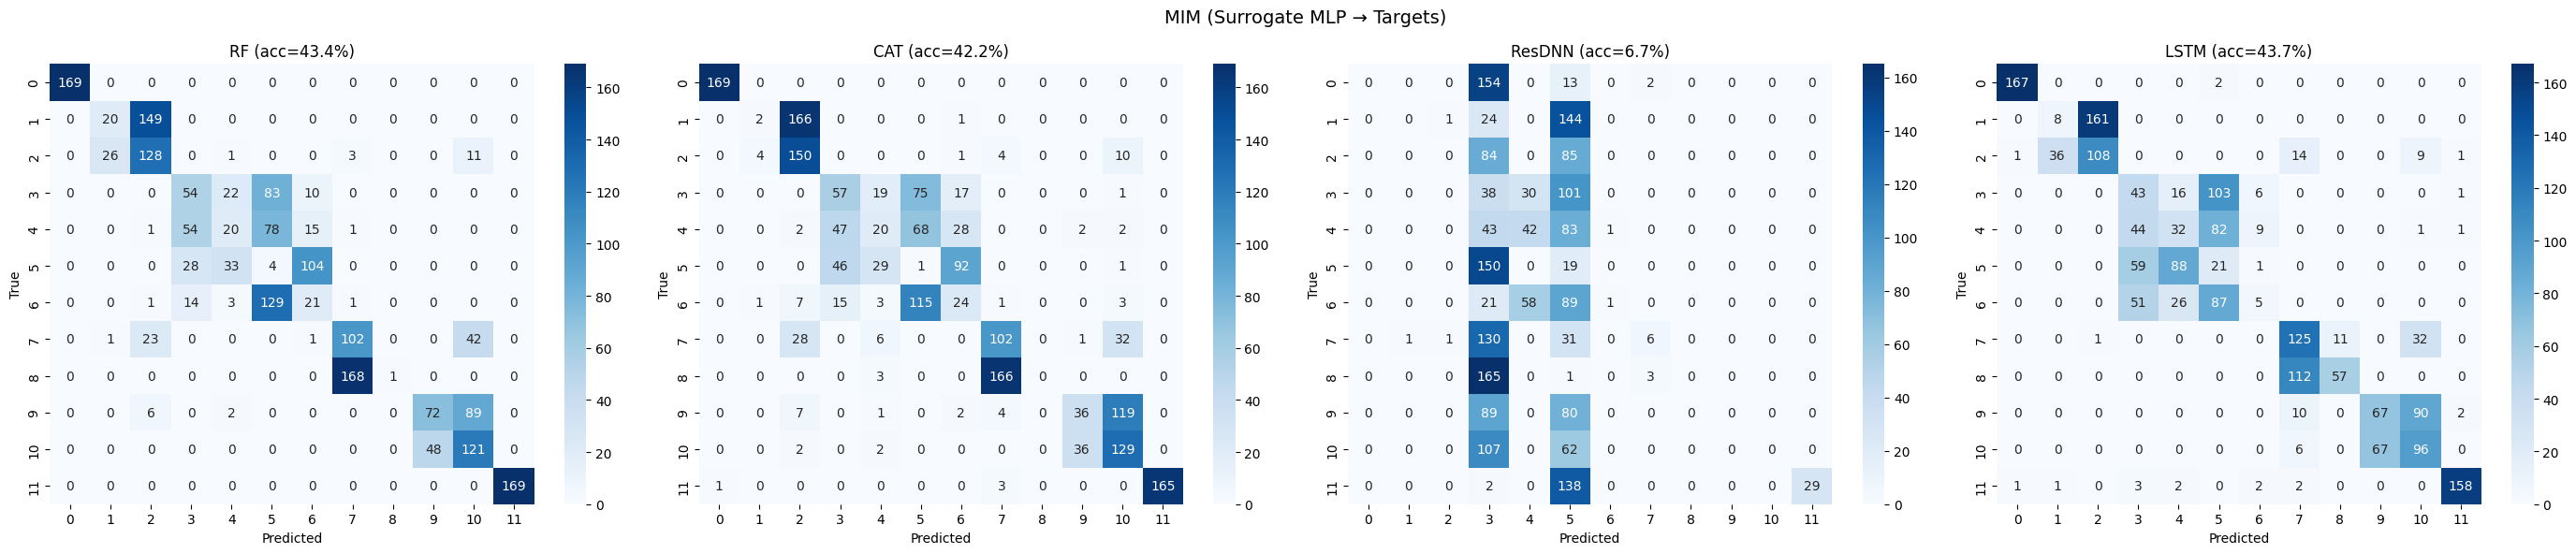

In [23]:
for atk_name in ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']:
    adv = surrogate_adv[atk_name]
    fig, axes = plt.subplots(1, 4, figsize=(28, 6))
    fig.suptitle(f'{atk_name.upper()} (Surrogate MLP → Targets)', fontsize=14)

    for ax, (tgt_name, tgt_clf) in zip(axes, target_classifiers.items()):
        preds = np.argmax(tgt_clf.predict(adv), axis=1)
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        acc = accuracy_score(y_test, preds) * 100
        ax.set_title(f'{tgt_name} (acc={acc:.1f}%)')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.show()